In [1]:
from spyplotter import Spectrum
%matplotlib widget
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import astropy.units as u
import numpy as np
from spyplotter.spec_tools.convolutions import gaussian_kernel
from astropy.constants import c

# Rotational Broadening

In [2]:
# import raw spectrum
raw_spec = Spectrum.from_powr(filepath='test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',keywords=['OPT'],dataset=1)
raw_spec_uv = Spectrum.from_powr(filepath='test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',keywords=["* IUE SHORT"],dataset=1)

# import broadened spectrum
spec_vrot100_opt = Spectrum.from_file(filename='test_data/test_convolutions/vrot100_opt.dat')
spec_vrot500_opt = Spectrum.from_file(filename='test_data/test_convolutions/vrot500_opt.dat')

spyplotter.spectrum - INFO - No flux unit specified and no signs for y units detected. Thus assuming normalized spectum.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - No flux unit specified and no signs for y units detected. Thus assuming normalized spectum.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


## Plot wrplot results

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


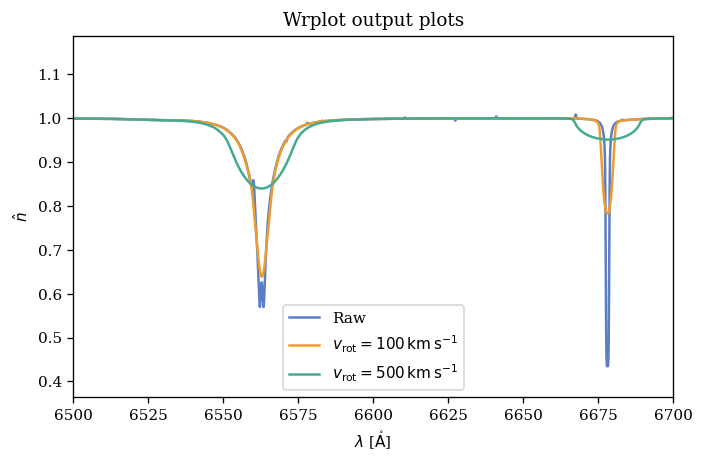

In [3]:
ax = raw_spec.plot(label='Raw',fig_width=6)
ax.set_title('Wrplot output plots')
spec_vrot100_opt.plot(label='$v_{\mathrm{rot}}=100\,\mathrm{km\,s^{-1}}$',ax=ax)
spec_vrot500_opt.plot(label='$v_{\mathrm{rot}}=500\,\mathrm{km\,s^{-1}}$',ax=ax)
ax.set_xlim(6500,6700)
ax.legend()

## Comparison of wrplot with Spyplotter

In [4]:
spec_100 = raw_spec.convolve_rotation(vsini=100,epsilon=0.01,new_spectrum=True)
spec_500 = raw_spec.convolve_rotation(vsini=500,epsilon=0.01,new_spectrum=True)

spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.
spyplotter.spectrum - WARNING - Spectrum is not equally spaced. Interpolating to equally spaced grid.
spyplotter.spec_tools.convolutions - WARNING - WARNING: broadened_flux (137970) is shorter than target length (137971). Padding with last value.
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.
spyplotter.spectrum - WARNING - Spectrum is not equally spaced. Interpolating to equally spaced grid.
spyplotter.spec_tools.convolutions - WARNING - WARNING: broadened_flux (137969) is shorter than target length (137970). Padding with last value.
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 


spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


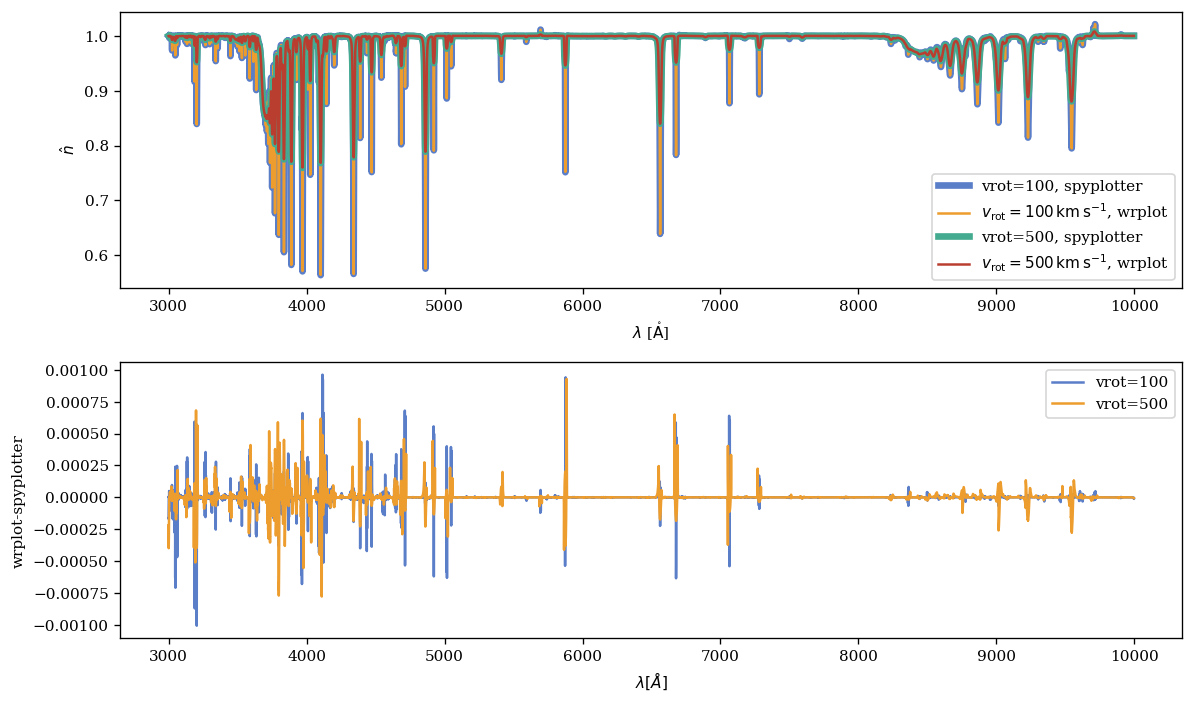

In [5]:
fig, (ax,ax2) = plt.subplots(2,1,figsize=(10,6))


#Show raw spectrum
#raw_spec.plot(label='Raw',ax=ax)

#vrot=100
spec_100.plot(ax=ax,label='vrot=100, spyplotter',lw=4)
spec_vrot100_opt.plot(label='$v_{\mathrm{rot}}=100\,\mathrm{km\,s^{-1}}$, wrplot',ax=ax)

#vrot=500
spec_500.plot(ax=ax,label='vrot=500, spyplotter',lw=4)
spec_vrot500_opt.plot(label='$v_{\mathrm{rot}}=500\,\mathrm{km\,s^{-1}}$, wrplot',ax=ax)
ax.legend()

# Show uncertainties
y_vrot500_interp = interp1d(spec_vrot100_opt.x.value,spec_vrot100_opt.y.value)
ax2.plot(spec_100.x.value,y_vrot500_interp(spec_100.x.value)-spec_100.y.value,label='vrot=100')

y_vrot500_interp = interp1d(spec_vrot500_opt.x.value,spec_vrot500_opt.y.value)
ax2.plot(spec_500.x.value,y_vrot500_interp(spec_500.x.value)-spec_500.y.value,label='vrot=500')
ax2.set_xlabel('$\lambda [\AA]$')
ax2.set_ylabel('wrplot-spyplotter')


ax2.legend()

## Plot kernel

In [6]:
from spyplotter.spec_tools.convolutions import rotational_broadening_kernel
from astropy.constants import c

In [7]:
vrot = 500 * u.km/u.s

wavelength = np.linspace(raw_spec.x_min.value, raw_spec.x_max.value,np.size(raw_spec.x.value))
bin_width = wavelength[1] - wavelength[0]

vc = (vrot / c).decompose().value
# maximum wavelength shift at midpoint of chunk
delta_lambda_L =  np.mean(wavelength) * vc

# Define convolution kernel
N = int(np.floor(delta_lambda_L / bin_width))
delta_lambda = np.arange(-N, N + 1) * bin_width
kernel = rotational_broadening_kernel(delta_lambda_L, delta_lambda)

In [8]:
delta_lambda_L

10.837781362439356

Text(0, 0.5, 'G($\\Delta \\lambda$)')

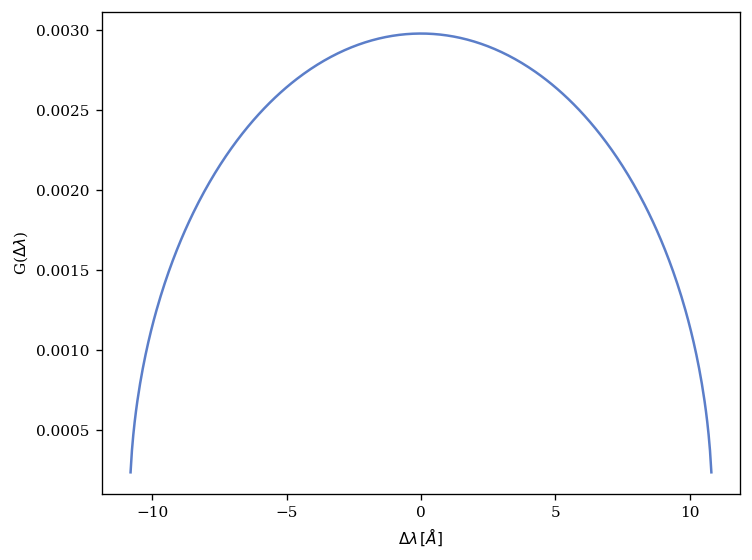

In [9]:
# Plot the kernel
fig, ax = plt.subplots()
ax.plot(delta_lambda,kernel)

ax.set_xlabel('$\Delta \lambda \, [\AA]$')
ax.set_ylabel('G($\Delta \lambda$)')

# Instrumental broadening

In [10]:
# import broadened spectrum
spec_06_opt = Spectrum.from_file(filename='test_data/test_convolutions/conv06_opt.dat')
spec_01_uv = Spectrum.from_file(filename='test_data/test_convolutions/conv01_uv.dat')

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


## Plot wrplot results

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


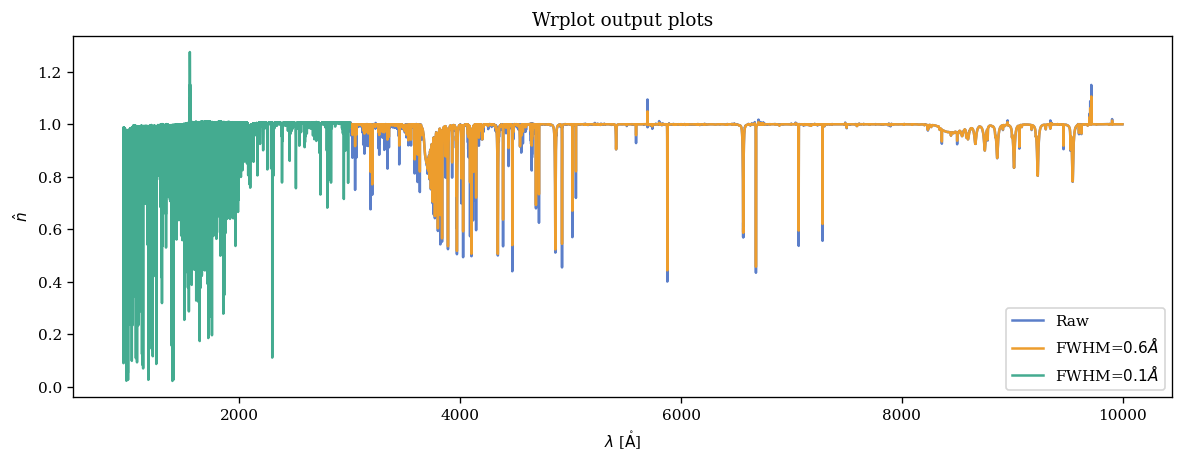

In [11]:
ax = raw_spec.plot(label='Raw',fig_width=10)
ax.set_title('Wrplot output plots')
spec_06_opt.plot(label='FWHM=$0.6 \AA$',ax=ax)
spec_01_uv.plot(label='FWHM=$0.1 \AA$',ax=ax)
#ax.set_xlim(6500,6700)
ax.legend()

## Comparison of wrplot with spyplotter

In [12]:
spec_06_spyplotter = raw_spec.convolve_gaussian(fwhm=0.6, new_spectrum=True)
# or sigma as input
spec_01_spyplotter_uv = raw_spec_uv.convolve_gaussian(fwhm=0.1, new_spectrum=True)

spyplotter.spectrum - WARNING - Spectrum is not equally spaced. Interpolating to equally spaced grid.
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spectrum - WARNING - Spectrum is not equally spaced. Interpolating to equally spaced grid.
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 


spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


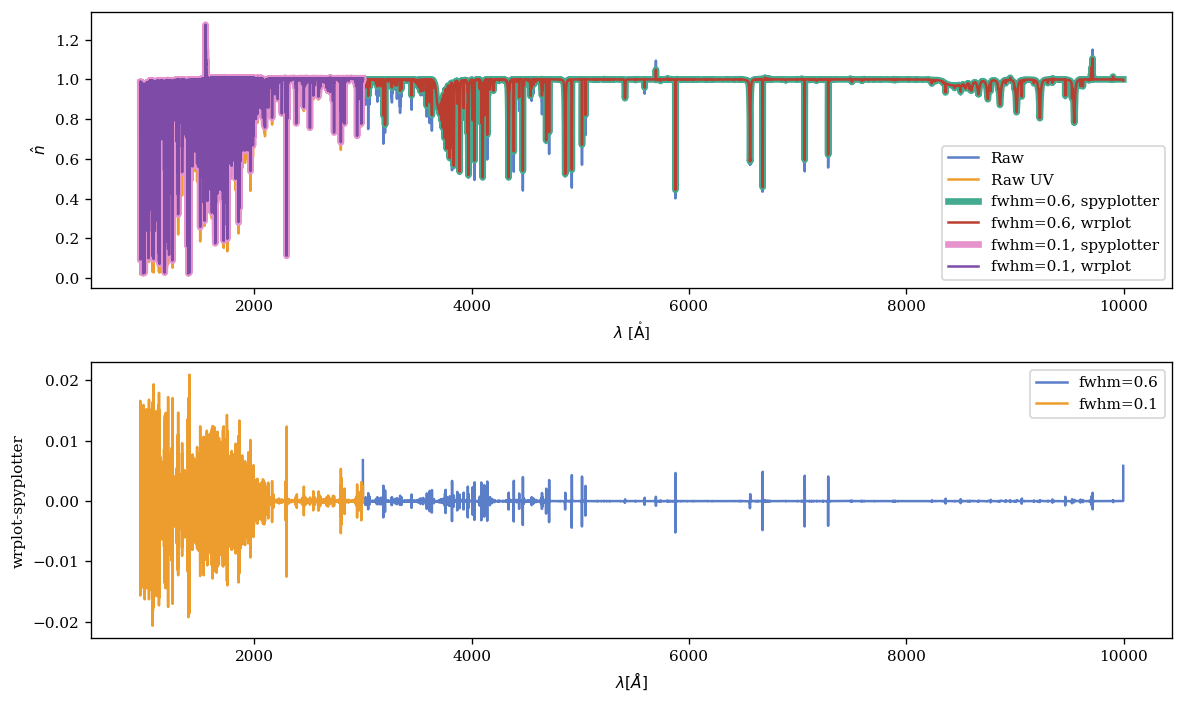

In [13]:
fig, (ax,ax2) = plt.subplots(2,1,figsize=(10,6))
#Show raw spectrum
raw_spec.plot(label='Raw',ax=ax)
raw_spec_uv.plot(label='Raw UV',ax=ax)

#fwhm=0.6
spec_06_opt.plot(ax=ax,label='fwhm=0.6, spyplotter',lw=4)
spec_06_spyplotter.plot(label='fwhm=0.6, wrplot',ax=ax)

#fwhm=0.6
spec_01_uv.plot(ax=ax,label='fwhm=0.1, spyplotter',lw=4)
spec_01_spyplotter_uv.plot(label='fwhm=0.1, wrplot',ax=ax)
ax.legend()

# Show uncertainties
y_06_interp = interp1d(spec_06_opt.x.value,spec_06_opt.y.value)
ax2.plot(spec_06_spyplotter.x.value,y_06_interp(spec_06_spyplotter.x.value)-spec_06_spyplotter.y.value,label='fwhm=0.6')

y_01_interp = interp1d(spec_01_uv.x.value,spec_01_uv.y.value)
ax2.plot(spec_01_spyplotter_uv.x.value,y_01_interp(spec_01_spyplotter_uv.x.value)-spec_01_spyplotter_uv.y.value,label='fwhm=0.1')

ax2.set_xlabel('$\lambda [\AA]$')
ax2.set_ylabel('wrplot-spyplotter')

ax2.legend()

## Plot kernel

In [14]:
from spyplotter.spec_tools.convolutions import gaussian_kernel
from astropy.constants import c

In [15]:
fwhm = 0.6

wavelength = np.linspace(raw_spec.x_min.value, raw_spec.x_max.value,np.size(raw_spec.x.value))
bin_width = wavelength[1] - wavelength[0]

# Define Gaussian kernel
delta_lambda = np.arange(-5 * fwhm, 5 * fwhm + bin_width, bin_width)
kernel = gaussian_kernel(delta_lambda, fwhm)

Text(0, 0.5, 'G($\\Delta \\lambda$)')

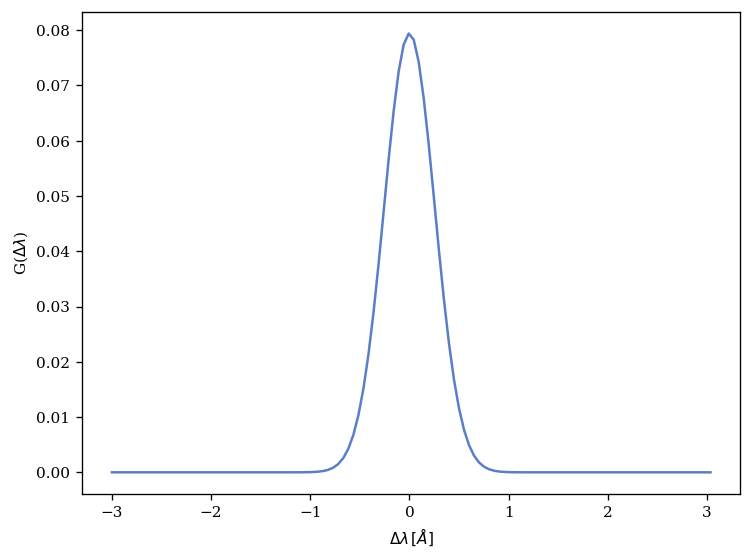

In [16]:
# Plot the kernel
fig, ax = plt.subplots()
ax.plot(delta_lambda,kernel)

ax.set_xlabel('$\Delta \lambda \, [\AA]$')
ax.set_ylabel('G($\Delta \lambda$)')

# Macroturbulence

## Plot wrplot results

In [17]:
# import broadened spectrum
spec_vmac10_opt_wrplot = Spectrum.from_file(filename='test_data/test_convolutions/vmac10_opt.dat')
spec_vmac100_opt_wrplot = Spectrum.from_file(filename='test_data/test_convolutions/vmac100_opt.dat')

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


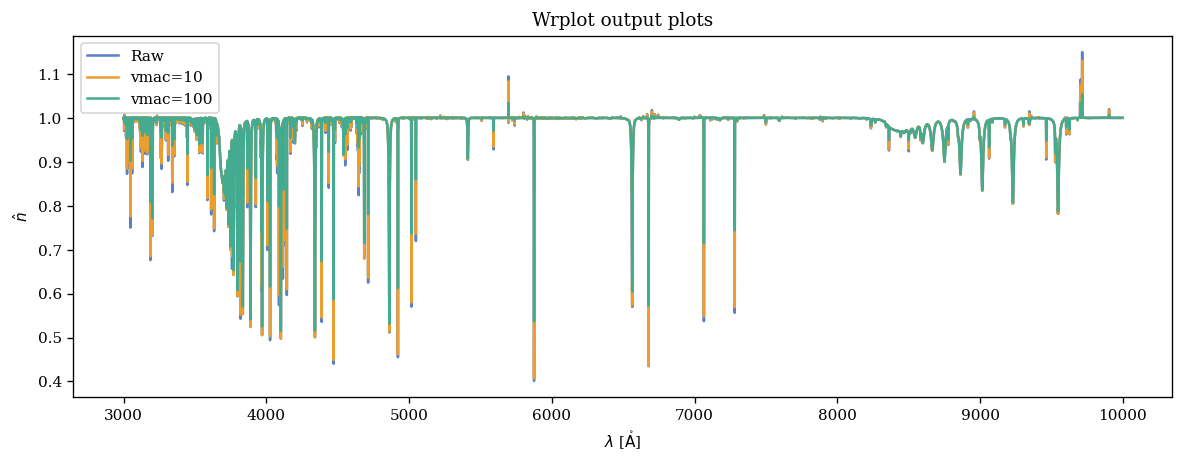

In [18]:
ax = raw_spec.plot(label='Raw',fig_width=10)
ax.set_title('Wrplot output plots')
spec_vmac10_opt_wrplot.plot(label='vmac=10',ax=ax)
spec_vmac100_opt_wrplot.plot(label='vmac=100',ax=ax)
#ax.set_xlim(6500,6700)
ax.legend()

## Comparison of wrplot with spyplotter

In [19]:
vmac10_spyplotter = raw_spec.convolve_macroturbulence(vmac=10*u.km/u.s,new_spectrum=True,epsilon=0.0005)
vmac100_spyplotter = raw_spec.convolve_macroturbulence(vmac=50*u.km/u.s,new_spectrum=True,epsilon=0.0005)

spyplotter.spectrum - WARNING - Spectrum is not equally spaced. Interpolating to equally spaced grid.
spyplotter.spec_tools.convolutions - WARNING - WARNING: broadened_flux (137967) is shorter than target length (137968). Padding with last value.
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spectrum - WARNING - Spectrum is not equally spaced. Interpolating to equally spaced grid.
spyplotter.spec_tools.convolutions - WARNING - WARNING: broadened_flux (137966) is shorter than target length (137967). Padding with last value.
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 


In [20]:
# Why do I need to take half here and why does my kernel not work? AHHHH

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


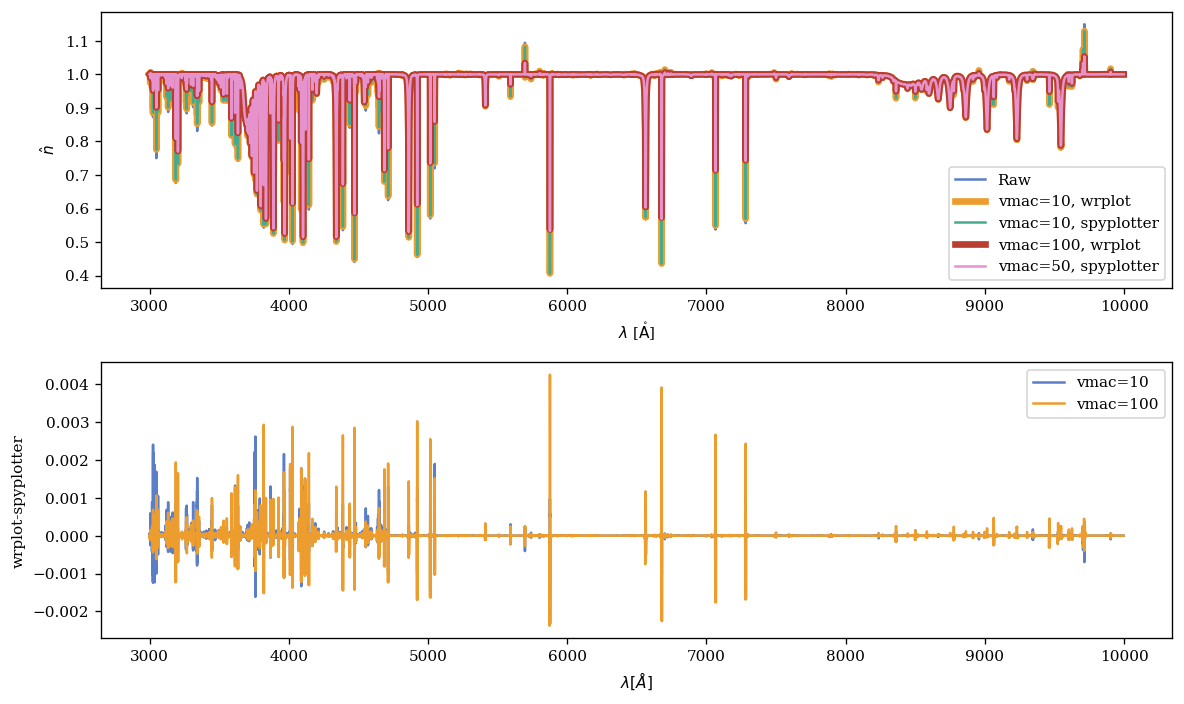

In [21]:
fig, (ax,ax2) = plt.subplots(2,1,figsize=(10,6))
#Show raw spectrum
raw_spec.plot(label='Raw',ax=ax)
#raw_spec_uv.plot(label='Raw UV',ax=ax)

#vmac=10
spec_vmac10_opt_wrplot.plot(ax=ax,label='vmac=10, wrplot',lw=4)
vmac10_spyplotter.plot(label='vmac=10, spyplotter',ax=ax)

#vmac=100
spec_vmac100_opt_wrplot.plot(ax=ax,label='vmac=100, wrplot',lw=4)
vmac100_spyplotter.plot(label='vmac=50, spyplotter',ax=ax)
ax.legend()

# Show uncertainties
y_10_interp = interp1d(spec_vmac10_opt_wrplot.x.value,spec_vmac10_opt_wrplot.y.value)
ax2.plot(vmac10_spyplotter.x.value,y_10_interp(vmac10_spyplotter.x.value)-vmac10_spyplotter.y.value,label='vmac=10')

y_100_interp = interp1d(spec_vmac100_opt_wrplot.x.value,spec_vmac100_opt_wrplot.y.value)
ax2.plot(vmac100_spyplotter.x.value,y_100_interp(vmac100_spyplotter.x.value)-vmac100_spyplotter.y.value,label='vmac=100')

ax2.set_xlabel('$\lambda [\AA]$')
ax2.set_ylabel('wrplot-spyplotter')

ax2.legend()

When using vmac/2, the results between Wrplot and spyplotter are the same but I don't understand where factor is coming from. For small macroturbulences (5-20), the difference should be negligible

## Plot kernel

In [22]:
from spyplotter.spec_tools.convolutions import macroturbulence_kernel
from astropy.constants import c
from scipy.special import erfc,erf

In [23]:
vmac = 100 * u.km/u.s

wavelength = np.linspace(raw_spec.x_min.value, raw_spec.x_max.value,np.size(raw_spec.x.value))
bin_width = wavelength[1] - wavelength[0]

vc = (vmac / c).decompose().value
delta_lambda_L_max = np.mean(wavelength) * vc

N = int(np.floor(2*delta_lambda_L_max / bin_width))
delta_lambda = np.arange(-N, N + 1) * bin_width

G = macroturbulence_kernel(delta_lambda_L_max, delta_lambda)

#G_powr = macroturbulence_kernel_powr(delta_lambda_L_max, delta_lambda)

In [24]:
vmac2 = 50 * u.km/u.s

vc2 = (vmac2 / c).decompose().value
delta_lambda_L_max2 = np.mean(wavelength) * vc2

N2 = int(np.floor(2*delta_lambda_L_max2 / bin_width))
delta_lambda2 = np.arange(-N2, N2 + 1) * bin_width
G2 = macroturbulence_kernel(delta_lambda_L_max2, delta_lambda2)

### Comparison with Gaussian kernel

2.167530893836391


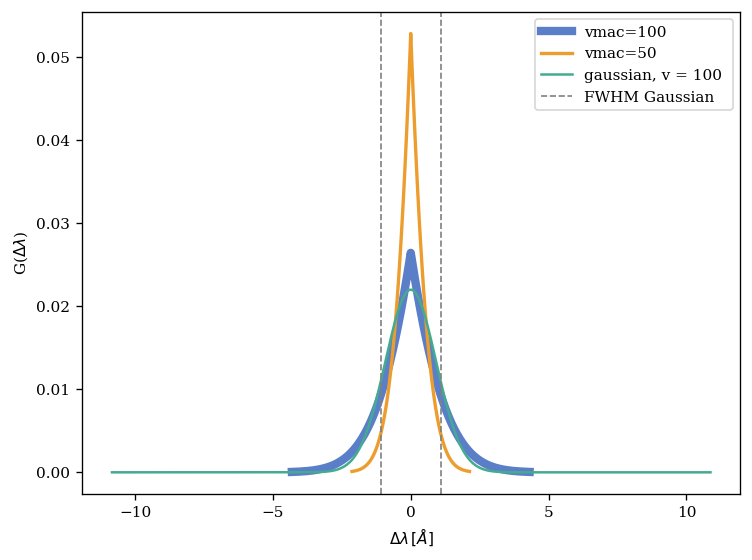

In [33]:
# Plot the kernel in delta lambda space
fig, ax = plt.subplots()
ax.plot(delta_lambda,G,label='vmac=100',lw=5)
ax.plot(delta_lambda2,G2,label='vmac=50',lw=2)
#ax.plot(delta_lambda,G1,label='G1')
#ax.plot(delta_lambda,G2,label='G2')

#Compare with Gaussian kernel
#fwhm = 0.6 # \AA
vc =  (100*u.km/u.s / c).decompose().value
l0 = np.mean(wavelength)
fwhm =  l0 * vc 
print(fwhm)

wavelength = np.linspace(raw_spec.x_min.value, raw_spec.x_max.value,np.size(raw_spec.x.value))
bin_width = wavelength[1] - wavelength[0]

# Define Gaussian kernel
delta_lambda_g = np.arange(-5 * fwhm, 5 * fwhm + bin_width, bin_width)
#print(delta_lambda_g,fwhm)
kernel_g = gaussian_kernel(delta_lambda_g, fwhm)
ax.plot(delta_lambda_g,kernel_g,label='gaussian, v = 100 ')

# Mark FWHM
# Here, the 2 is needed to convert from widthhhh!!! to radius of kernel
ax.axvline(-fwhm/2,color='grey',label='FWHM Gaussian',lw=1,ls='--')
ax.axvline(fwhm/2,color='grey',lw=1,ls='--')


ax.set_xlabel('$\Delta \lambda \, [\AA]$')
ax.set_ylabel('G($\Delta \lambda$)')
ax.legend()



In [41]:
-fwhm/2/l0*c.to(u.km/u.s).value

-50.0

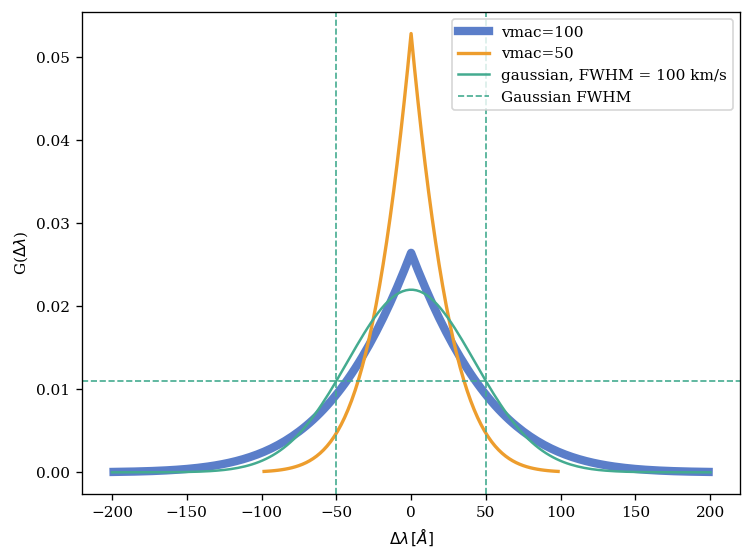

In [50]:
# Plot the kernel in velocity space delta lambda/lambda_0 \approx v/c
fig, ax = plt.subplots()
ax.plot(delta_lambda/l0*c.to(u.km/u.s),G,label='vmac=100',lw=5)
ax.plot(delta_lambda2/l0*c.to(u.km/u.s),G2,label='vmac=50',lw=2)

#Compare with Gaussian kernel
#fwhm = 0.6 # \AA
vc =  (100*u.km/u.s / c).decompose().value
fwhm = np.mean(wavelength) * vc 

wavelength = np.linspace(raw_spec.x_min.value, raw_spec.x_max.value,np.size(raw_spec.x.value))
bin_width = wavelength[1] - wavelength[0]

# Define Gaussian kernel
delta_lambda_g = np.arange(-2 * fwhm, 2 * fwhm + bin_width, bin_width)
#print(delta_lambda_g,fwhm)
kernel_g = gaussian_kernel(delta_lambda_g, fwhm)
ax.plot(delta_lambda_g/l0*c.to(u.km/u.s),kernel_g,label='gaussian, FWHM = 100 km/s')

# Mark FWHM
#Here, the 2 is needed to convert from widthhhh!!! to radius of kernel
ax.axvline(-fwhm/2/l0*c.to(u.km/u.s).value,color='C02',label='Gaussian FWHM',lw=1,ls='--')
ax.axvline(fwhm/2/l0*c.to(u.km/u.s).value,color='C02',lw=1,ls='--')
ax.axhline(max(kernel_g)/2,color='C02',lw=1,ls='--')


ax.set_xlabel('$\Delta \lambda \, [\AA]$')
ax.set_ylabel('G($\Delta \lambda$)')
ax.legend()

